In [1]:
import os 
import numpy as np
import pandas as pd
from scipy.stats import zscore

import scanpy as sc 

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ddir = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized" 
# !ls -alhtr $ddir

In [3]:
ddir2 = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/astro_john/cellchat_from_riki"
!ls $ddir2

28nr_vs_28dr_celladhesion.R	     ECM-Receptor_p28nr_vs_28dr.csv
Cell-Cell_Contact_p28nr_vs_28dr.csv  Secreted_Signaling_p28nr_vs_28dr.csv


In [4]:
f = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/merfish_genes.txt"
genes_mer = np.loadtxt(f, dtype=str)
genes_mer.shape

(500,)

# CellChat data

In [5]:
f1 = os.path.join(ddir2, 'Cell-Cell_Contact_p28nr_vs_28dr.csv')
f2 = os.path.join(ddir2, 'ECM-Receptor_p28nr_vs_28dr.csv')

df1 = pd.read_csv(f1, index_col=0)
df2 = pd.read_csv(f2, index_col=0)

df1

,ID,source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,pval.y,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INTastX,INTastY,INT
1,AST_AST_CADM1_CADM1,AST,AST,Cadm1,Cadm1,0.442968,0.0,CADM1_CADM1,Cadm1 - Cadm1,CADM,...,0.00,CADM1_CADM1,Cadm1 - Cadm1,CADM,Cell-Cell Contact,PMID: 24503895,0.011429,AST_AST,AST_AST,AST_AST_AST_AST
2,AST_AST_CDH2_CDH2,AST,AST,Cdh2,Cdh2,0.277887,0.0,CDH2_CDH2,Cdh2 - Cdh2,CDH,...,NaN,NaN,NaN,NaN,NaN,NaN,0.556131,AST_AST,NA_NA,AST_AST_NA_NA
3,AST_AST_CDH4_CDH4,AST,AST,Cdh4,Cdh4,0.015306,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.056838,AST_AST,AST_AST,AST_AST_AST_AST
4,AST_AST_JAM2_JAM2,AST,AST,Jam2,Jam2,0.012186,0.0,JAM2_JAM2,Jam2 - Jam2,JAM,...,NaN,NaN,NaN,NaN,NaN,NaN,1.914150,AST_AST,NA_NA,AST_AST_NA_NA
5,AST_AST_LRRC4B_PTPRF,AST,AST,Lrrc4b,Ptprf,0.013946,0.0,LRRC4B_PTPRF,Lrrc4b - Ptprf,NGL,...,NaN,NaN,NaN,NaN,NaN,NaN,1.855541,AST_AST,NA_NA,AST_AST_NA_NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4746,Vlp_Vlp_NRXN3_NLGN1,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,0.00,NRXN3_NLGN1,Nrxn3 - Nlgn1,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.305114,NA_NA,Vlp_Vlp,NA_NA_Vlp_Vlp
4747,Vlp_Vlp_NRXN3_NLGN2,Vlp,Vlp,Nrxn3,Nlgn2,0.090448,0.0,NRXN3_NLGN2,Nrxn3 - Nlgn2,NRXN,...,0.01,NRXN3_NLGN2,Nrxn3 - Nlgn2,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.025210,Vlp_Vlp,Vlp_Vlp,Vlp_Vlp_Vlp_Vlp
4748,Vlp_Vlp_PTPRM_PTPRM,Vlp,Vlp,Ptprm,Ptprm,0.143255,0.0,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.508049,Vlp_Vlp,Vlp_Vlp,Vlp_Vlp_Vlp_Vlp
4749,Vlp_Vlp_SEMA6A_PLXNA2,Vlp,Vlp,Sema6a,Plxna2,0.102426,0.0,SEMA6A_PLXNA2,Sema6a - Plxna2,SEMA6,...,0.00,SEMA6A_PLXNA2,Sema6a - Plxna2,SEMA6,Cell-Cell Contact,PMID: 27533782,0.039484,Vlp_Vlp,Vlp_Vlp,Vlp_Vlp_Vlp_Vlp


# forget about `.y` for now

In [6]:
cond = np.logical_xor(
    df1['source.x'] == 'AST', 
    df1['target.x'] == 'AST', 
)

print(cond.sum())
df1sub = df1[cond]
df1sub

373


,ID,source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,pval.y,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INTastX,INTastY,INT
13,AST_INH_CDH4_CDH4,AST,INH,Cdh4,Cdh4,0.014647,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,NaN,NaN,NaN,NaN,NaN,NaN,1.834258,AST_INH,NA_NA,AST_INH_NA_NA
14,AST_INH_NCAM1_NCAM1,AST,INH,Ncam1,Ncam1,0.341554,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,...,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,Cell-Cell Contact,KEGG: mmu04514,0.002556,AST_INH,AST_INH,AST_INH_AST_INH
16,AST_L2/3_CADM1_CADM1,AST,L2/3,Cadm1,Cadm1,0.378108,0.0,CADM1_CADM1,Cadm1 - Cadm1,CADM,...,0.0,CADM1_CADM1,Cadm1 - Cadm1,CADM,Cell-Cell Contact,PMID: 24503895,0.002496,AST_L2/3,AST_L2/3,AST_L2/3_AST_L2/3
17,AST_L2/3_CDH4_CDH4,AST,L2/3,Cdh4,Cdh4,0.033974,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.415612,AST_L2/3,AST_L2/3,AST_L2/3_AST_L2/3
18,AST_L2/3_JAM2_ITGAV_ITGB1,AST,L2/3,Jam2,ITGAV_ITGB1,0.029990,0.0,JAM2_ITGAV_ITGB1,Jam2 - (Itgav+Itgb1),JAM,...,NaN,NaN,NaN,NaN,NaN,NaN,1.523031,AST_L2/3,NA_NA,AST_L2/3_NA_NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4470,Vlp_AST_NCAM1_NCAM1,Vlp,AST,Ncam1,Ncam1,0.317634,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,...,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,Cell-Cell Contact,KEGG: mmu04514,0.003489,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST
4471,Vlp_AST_NRXN2_NLGN1,Vlp,AST,Nrxn2,Nlgn1,0.310005,0.0,NRXN2_NLGN1,Nrxn2 - Nlgn1,NRXN,...,0.0,NRXN2_NLGN1,Nrxn2 - Nlgn1,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.012166,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST
4472,Vlp_AST_NRXN3_NLGN1,Vlp,AST,Nrxn3,Nlgn1,0.485558,0.0,NRXN3_NLGN1,Nrxn3 - Nlgn1,NRXN,...,0.0,NRXN3_NLGN1,Nrxn3 - Nlgn1,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.011489,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST
4473,Vlp_AST_PTPRM_PTPRM,Vlp,AST,Ptprm,Ptprm,0.146098,0.0,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.0,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.228959,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST


In [7]:
df1sub.columns

Index(['ID', 'source.x', 'target.x', 'ligand.x', 'receptor.x', 'prob.x',
       'pval.x', 'interaction_name.x', 'interaction_name_2.x',
       'pathway_name.x', 'annotation.x', 'evidence.x', 'source.y', 'target.y',
       'ligand.y', 'receptor.y', 'prob.y', 'pval.y', 'interaction_name.y',
       'interaction_name_2.y', 'pathway_name.y', 'annotation.y', 'evidence.y',
       'abslogPdif', 'INTastX', 'INTastY', 'INT'],
      dtype='object')

In [8]:
a = df1sub.iloc[1]
b = df1sub.iloc[-1]
a

ID                      AST_INH_NCAM1_NCAM1
source.x                                AST
target.x                                INH
ligand.x                              Ncam1
receptor.x                            Ncam1
prob.x                             0.341554
pval.x                                  0.0
interaction_name.x              NCAM1_NCAM1
interaction_name_2.x         Ncam1  - Ncam1
pathway_name.x                         NCAM
annotation.x              Cell-Cell Contact
evidence.x                   KEGG: mmu04514
source.y                                AST
target.y                                INH
ligand.y                              Ncam1
receptor.y                            Ncam1
prob.y                              0.34357
pval.y                                  0.0
interaction_name.y              NCAM1_NCAM1
interaction_name_2.y         Ncam1  - Ncam1
pathway_name.y                         NCAM
annotation.y              Cell-Cell Contact
evidence.y                   KEG

In [9]:
a

ID                      AST_INH_NCAM1_NCAM1
source.x                                AST
target.x                                INH
ligand.x                              Ncam1
receptor.x                            Ncam1
prob.x                             0.341554
pval.x                                  0.0
interaction_name.x              NCAM1_NCAM1
interaction_name_2.x         Ncam1  - Ncam1
pathway_name.x                         NCAM
annotation.x              Cell-Cell Contact
evidence.x                   KEGG: mmu04514
source.y                                AST
target.y                                INH
ligand.y                              Ncam1
receptor.y                            Ncam1
prob.y                              0.34357
pval.y                                  0.0
interaction_name.y              NCAM1_NCAM1
interaction_name_2.y         Ncam1  - Ncam1
pathway_name.y                         NCAM
annotation.y              Cell-Cell Contact
evidence.y                   KEG

In [10]:
b

ID                      Vlp_AST_SEMA4D_PLXNB1
source.x                                  Vlp
target.x                                  AST
ligand.x                               Sema4d
receptor.x                             Plxnb1
prob.x                               0.037424
pval.x                                    0.0
interaction_name.x              SEMA4D_PLXNB1
interaction_name_2.x         Sema4d  - Plxnb1
pathway_name.x                          SEMA4
annotation.x                Cell-Cell Contact
evidence.x                     PMID: 27533782
source.y                                  Vlp
target.y                                  AST
ligand.y                               Sema4d
receptor.y                             Plxnb1
prob.y                               0.013181
pval.y                                    0.0
interaction_name.y              SEMA4D_PLXNB1
interaction_name_2.y         Sema4d  - Plxnb1
pathway_name.y                          SEMA4
annotation.y                Cell-C

In [11]:
-np.log10(a['prob.x'])

0.4665412032363596

In [12]:
np.abs(-np.log10(b['prob.x'])-(-np.log10(b['prob.y'])))

0.45321867342225874

In [13]:
df1sub['ligand.x'].unique()

array(['Cdh4', 'Ncam1', 'Cadm1', 'Jam2', 'Lrrc4b', 'Nrxn1', 'Nrxn2',
       'Sema4a', 'Lrrc4c', 'Nrxn3', 'Ptprm', 'Cdh2', 'Negr1', 'Nectin3',
       'Sema6d', 'Cntn1', 'Efnb2', 'Jag2', 'Jam3', 'Sema4d', 'Nectin1'],
      dtype=object)

In [14]:
df1sub['ligand.y'].unique()

array([nan, 'Ncam1', 'Cadm1', 'Cdh4', 'Nrxn1', 'Nrxn2', 'Lrrc4c', 'Ptprm',
       'Negr1', 'Nectin3', 'Sema4a', 'Cntn1', 'Efnb2', 'Sema4d', 'Jag2',
       'Nectin1', 'Nrxn3'], dtype=object)

In [15]:
df1sub['receptor.x'].unique()

array(['Cdh4', 'Ncam1', 'Cadm1', 'ITGAV_ITGB1', 'Jam3', 'Ptprf', 'L1cam',
       'Nlgn1', 'Nlgn2', 'NRP1_PLXNA2', 'NRP1_PLXNA4', 'Ntng1', 'Ncam2',
       'Nlgn3', 'Ptprm', 'Cdh2', 'Negr1', 'Nectin1', 'Fgfr1',
       'NRP1_PLXNA1', 'Plxna1', 'Jam2', 'Nrcam', 'Ephb1', 'Notch1',
       'Notch2', 'Plxnb1', 'Nectin3'], dtype=object)

In [16]:
df1sub['receptor.y'].unique()

array([nan, 'Ncam1', 'Cadm1', 'Cdh4', 'L1cam', 'Nlgn1', 'Nlgn2', 'Ntng1',
       'Ncam2', 'Ptprm', 'Negr1', 'Nectin1', 'NRP1_PLXNA2', 'NRP1_PLXNA4',
       'Fgfr1', 'Nrcam', 'Ephb1', 'Plxnb1', 'Notch1', 'Notch2', 'Nectin3'],
      dtype=object)

In [17]:
ligands = df1sub['ligand.x'].unique()
receptors = df1sub['receptor.x'].unique()
mols = np.union1d(ligands, receptors)
len(ligands), len(receptors), len(mols)

(21, 28, 39)

In [18]:
mols_mer = np.intersect1d(mols, genes_mer)
len(mols_mer), mols_mer

(11,
 array(['Cdh4', 'Ncam2', 'Negr1', 'Nrxn1', 'Nrxn2', 'Ntng1', 'Plxna1',
        'Ptprf', 'Ptprm', 'Sema4a', 'Sema6d'], dtype=object))

# subselect

In [19]:
cond2 = np.logical_and(
    df1sub['ligand.x'].isin(mols_mer),
    df1sub['receptor.x'].isin(mols_mer),
)
# cond2 = np.logical_or(
#     df1sub['ligand.x'].isin(mols_mer),
#     df1sub['receptor.x'].isin(mols_mer),
# )
df1sub2 = df1sub[cond2]
df1sub2

,ID,source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,pval.y,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INTastX,INTastY,INT
13,AST_INH_CDH4_CDH4,AST,INH,Cdh4,Cdh4,0.014647,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,NaN,NaN,NaN,NaN,NaN,NaN,1.834258,AST_INH,NA_NA,AST_INH_NA_NA
17,AST_L2/3_CDH4_CDH4,AST,L2/3,Cdh4,Cdh4,0.033974,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.415612,AST_L2/3,AST_L2/3,AST_L2/3_AST_L2/3
36,AST_L2/3/4_CDH4_CDH4,AST,L2/3/4,Cdh4,Cdh4,0.009749,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,NaN,NaN,NaN,NaN,NaN,NaN,2.011027,AST_L2/3/4,NA_NA,AST_L2/3/4_NA_NA
52,AST_L2/3/4_PTPRM_PTPRM,AST,L2/3/4,Ptprm,Ptprm,0.033663,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.072057,AST_L2/3/4,AST_L2/3/4,AST_L2/3/4_AST_L2/3/4
57,AST_L4_CDH4_CDH4,AST,L4,Cdh4,Cdh4,0.009848,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,NaN,NaN,NaN,NaN,NaN,NaN,2.006651,AST_L4,NA_NA,AST_L4_NA_NA
65,AST_L4_NEGR1_NEGR1,AST,L4,Negr1,Negr1,0.424635,0.00,NEGR1_NEGR1,Negr1 - Negr1,NEGR,...,0.00,NEGR1_NEGR1,Negr1 - Negr1,NEGR,Cell-Cell Contact,KEGG: mmu04514,0.015313,AST_L4,AST_L4,AST_L4_AST_L4
70,AST_L4_PTPRM_PTPRM,AST,L4,Ptprm,Ptprm,0.039488,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.067144,AST_L4,AST_L4,AST_L4_AST_L4
87,AST_L4/L5IT_PTPRM_PTPRM,AST,L4/L5IT,Ptprm,Ptprm,0.192742,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.024432,AST_L4/L5IT,AST_L4/L5IT,AST_L4/L5IT_AST_L4/L5IT
103,AST_L5IT_PTPRM_PTPRM,AST,L5IT,Ptprm,Ptprm,0.230858,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.017004,AST_L5IT,AST_L5IT,AST_L5IT_AST_L5IT
126,AST_L5PT_CDH4_CDH4,AST,L5PT,Cdh4,Cdh4,0.039693,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.018509,AST_L5PT,AST_L5PT,AST_L5PT_AST_L5PT


In [20]:
terms = df1sub2['ID'].values
assert len(np.unique(terms)) == len(terms)
len(terms), terms

(44,
 array(['AST_INH_CDH4_CDH4', 'AST_L2/3_CDH4_CDH4', 'AST_L2/3/4_CDH4_CDH4',
        'AST_L2/3/4_PTPRM_PTPRM', 'AST_L4_CDH4_CDH4', 'AST_L4_NEGR1_NEGR1',
        'AST_L4_PTPRM_PTPRM', 'AST_L4/L5IT_PTPRM_PTPRM',
        'AST_L5IT_PTPRM_PTPRM', 'AST_L5PT_CDH4_CDH4',
        'AST_L5PT_PTPRM_PTPRM', 'AST_L5PT_SEMA6D_PLXNA1',
        'AST_L6CTb_CDH4_CDH4', 'AST_L6CTb_PTPRM_PTPRM',
        'AST_L6IT_CDH4_CDH4', 'AST_L6IT_SEMA6D_PLXNA1',
        'AST_Pvalb_PTPRM_PTPRM', 'AST_Pvalb_SEMA6D_PLXNA1',
        'AST_Sst_CDH4_CDH4', 'AST_Sst_NEGR1_NEGR1', 'AST_Sst_PTPRM_PTPRM',
        'AST_Sst_SEMA6D_PLXNA1', 'AST_Vlp_CDH4_CDH4',
        'AST_Vlp_PTPRM_PTPRM', 'INH_AST_CDH4_CDH4', 'L2/3_AST_CDH4_CDH4',
        'L2/3/4_AST_CDH4_CDH4', 'L2/3/4_AST_PTPRM_PTPRM',
        'L4_AST_CDH4_CDH4', 'L4_AST_NEGR1_NEGR1', 'L4_AST_PTPRM_PTPRM',
        'L4/L5IT_AST_PTPRM_PTPRM', 'L5IT_AST_PTPRM_PTPRM',
        'L5PT_AST_CDH4_CDH4', 'L5PT_AST_PTPRM_PTPRM',
        'L6CTb_AST_CDH4_CDH4', 'L6CTb_AST_PTPRM_PTPRM',
 

<Axes: xlabel='prob.x', ylabel='Count'>

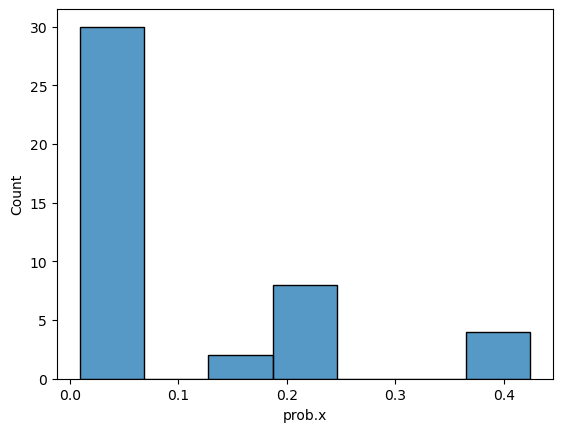

In [21]:
sns.histplot(df1sub2['prob.x'])

<Axes: xlabel='prob.y', ylabel='Count'>

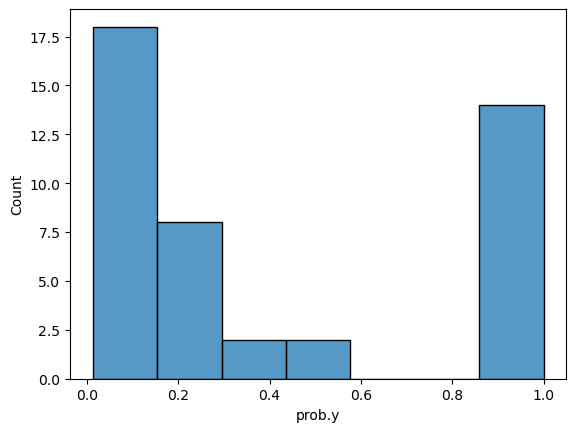

In [22]:
sns.histplot(df1sub2['prob.y'])

In [23]:
summary = df1sub2.groupby(['INTastX', 'interaction_name.x']).size().unstack().fillna(0).astype(int)
summary


interaction_name.x,CDH4_CDH4,NEGR1_NEGR1,PTPRM_PTPRM,SEMA6D_PLXNA1
INTastX,,,,
AST_INH,1,0,0,0
AST_L2/3,1,0,0,0
AST_L2/3/4,1,0,1,0
AST_L4,1,1,1,0
AST_L4/L5IT,0,0,1,0
AST_L5IT,0,0,1,0
AST_L5PT,1,0,1,1
AST_L6CTb,1,0,1,0
AST_L6IT,1,0,0,1


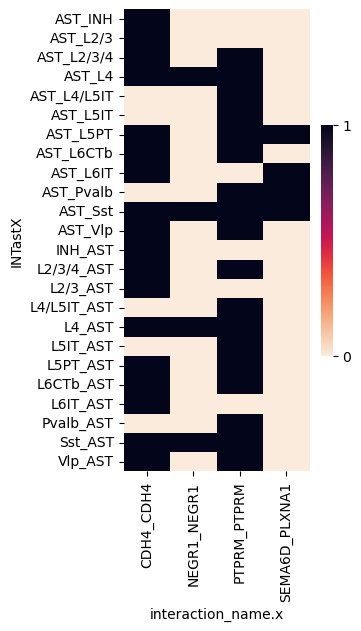

In [24]:
fig, ax = plt.subplots(figsize=(3,6))
sns.heatmap(summary, 
            cbar_kws={'shrink':0.5, 'ticks': [0,1]}, cmap='rocket_r')
plt.show()

# Just 4 pairs of interactions? 

In [25]:
df1sub2['ligand.x'].unique(), df1sub2['receptor.x'].unique()

(array(['Cdh4', 'Ptprm', 'Negr1', 'Sema6d'], dtype=object),
 array(['Cdh4', 'Ptprm', 'Negr1', 'Plxna1'], dtype=object))

In [26]:
genes_cellchat = np.unique(np.hstack([df1sub2['ligand.x'], df1sub2['receptor.x']]))
genes_cellchat

array(['Cdh4', 'Negr1', 'Plxna1', 'Ptprm', 'Sema6d'], dtype=object)

# MERFISH data - check these 5 genes

In [27]:
f = os.path.join(ddir, "P28NRDR_v1glut_rna_merfish_240729.h5ad")
adata = sc.read(f)
adata

AnnData object with n_obs × n_vars = 36376 × 361
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass', 'modality', 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show', 'leiden_r0.3', 'umap1', 'umap2', 'umap1_self', 'umap2_self', 'max_pred', 'frac_self_neighbors', 'gated_pred', 'max_pred_subclass', 'frac_self_neighbors_subclass', 'gated_pred_subclass'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca2', 'X_pca_harmony', 'X_umap', 'X_xy', 'blanks', 'pca', 'umap'
    layers: 'jnorm', 'ljnorm', 'lognorm', 'norm'
    obsp: 'connectiv

In [28]:
adata.var

""
6530403H02Rik
Abcg1
Adamts17
Adamts2
Adipor2
...
Zfp608
Zfp804a
Zfp804b
Zfpm2


In [29]:
genes_cellchat_mer = np.intersect1d(adata.var.index.values, genes_cellchat)
genes_cellchat_mer

array(['Cdh4', 'Negr1', 'Ptprm', 'Sema6d'], dtype=object)

In [30]:
adata_rna = adata[adata.obs['modality']=='rna']
adata_mer = adata[adata.obs['modality']=='merfish']
adata_mer

View of AnnData object with n_obs × n_vars = 21061 × 361
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass', 'modality', 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show', 'leiden_r0.3', 'umap1', 'umap2', 'umap1_self', 'umap2_self', 'max_pred', 'frac_self_neighbors', 'gated_pred', 'max_pred_subclass', 'frac_self_neighbors_subclass', 'gated_pred_subclass'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca2', 'X_pca_harmony', 'X_umap', 'X_xy', 'blanks', 'pca', 'umap'
    layers: 'jnorm', 'ljnorm', 'lognorm', 'norm'
    obsp: 'c

In [31]:
dfval = adata_rna.obs[['Subclass']].copy()
dfval[genes_cellchat_mer] = np.array(adata_rna[:,genes_cellchat_mer].layers['lognorm'].todense())
dfval

,Subclass,Cdh4,Negr1,Ptprm,Sema6d
AAACCCACAAATGATG-1-P28_1a-P28,L6CT,0.000000,1.155847,0.000000,0.884139
AAACCCACACCCTAGG-1-P28_1a-P28,L4,0.000000,1.586185,0.219852,0.694968
AAACCCAGTTCTCTCG-1-P28_1a-P28,L2/3,0.000000,1.275133,0.202691,1.089909
AAACCCATCACTTGTT-1-P28_1a-P28,L6CT,0.000000,1.106168,0.251546,1.106168
AAACCCATCCTAGCTC-1-P28_1a-P28,L4,0.391645,1.481162,0.391645,0.956750
...,...,...,...,...,...
TTTGGTTTCGTTCCCA-1-P28_2b-P28,L4,0.000000,1.709745,0.289640,1.124731
TTTGTTGAGCCGATTT-1-P28_2b-P28,L4,0.282244,1.530865,0.000000,0.573567
TTTGTTGCAAGTGATA-1-P28_2b-P28,L2/3,0.338722,1.065655,0.000000,0.338722
TTTGTTGTCCTAAGTG-1-P28_2b-P28,L4,0.000000,1.334684,0.000000,1.006922


In [32]:
dfval_mean = dfval.groupby('Subclass').mean()
dfval_mean

,Cdh4,Negr1,Ptprm,Sema6d
Subclass,,,,
L2/3,0.219489,1.263767,0.038471,0.555345
L4,0.086929,1.448082,0.238790,0.677189
L5IT,0.015396,1.230167,0.967485,0.596224
L5NP,0.008247,1.294839,0.016294,0.307878
L5PT,0.313179,1.067826,0.178889,0.715275
L6CT,0.032217,1.218519,0.013197,0.857219
L6IT,0.125907,1.271302,0.046880,0.444427
L6b,0.005715,1.338923,0.011738,0.317807


In [33]:
dfval_mean_zscore = zscore(dfval_mean, axis=0)
dfval_mean_zscore.mean()

Cdh4     -8.326673e-17
Negr1     1.360023e-15
Ptprm     5.551115e-17
Sema6d   -1.110223e-16
dtype: float64

<Axes: ylabel='Subclass'>

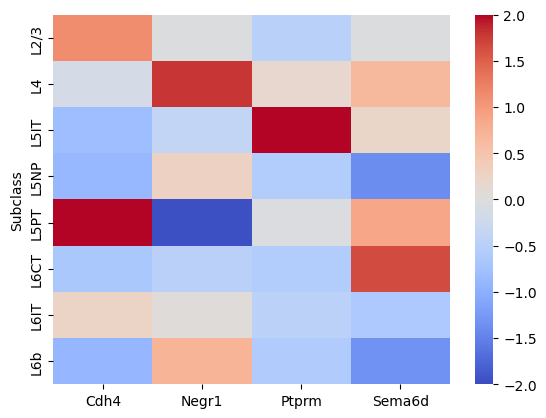

In [34]:
sns.heatmap(dfval_mean_zscore, vmax=2, vmin=-2, cmap='coolwarm')

In [35]:
sel_adata = adata_rna
sel_col = 'Subclass'
sel_layer = 'lognorm'
sel_genes = genes_cellchat_mer
sel_data = np.array(sel_adata[:,sel_genes].layers[sel_layer].todense())

dfval = sel_adata.obs[[sel_col]].copy()
dfval[sel_genes] = sel_data
dfval_mean = dfval.groupby(sel_col).mean()
dfval_mean_zscore = zscore(dfval_mean, axis=0)
print(dfval_mean.mean())

Cdh4      0.100885
Negr1     1.266678
Ptprm     0.188968
Sema6d    0.558920
dtype: float64


In [36]:
sel_adata = adata_mer 
sel_col = 'gated_pred_subclass'
sel_layer = 'ljnorm'
sel_genes = genes_cellchat_mer
sel_data = np.array(sel_adata[:,sel_genes].layers[sel_layer])

dfval2 = sel_adata.obs[[sel_col]].copy()
dfval2[sel_genes] = sel_data
dfval2_mean = dfval2.groupby(sel_col).mean()
dfval2_mean = dfval2_mean.drop('NA')
dfval2_mean_zscore = zscore(dfval2_mean, axis=0)
print(dfval2_mean.mean())

Cdh4      0.234792
Negr1     0.351146
Ptprm     0.367882
Sema6d    0.143032
dtype: float64


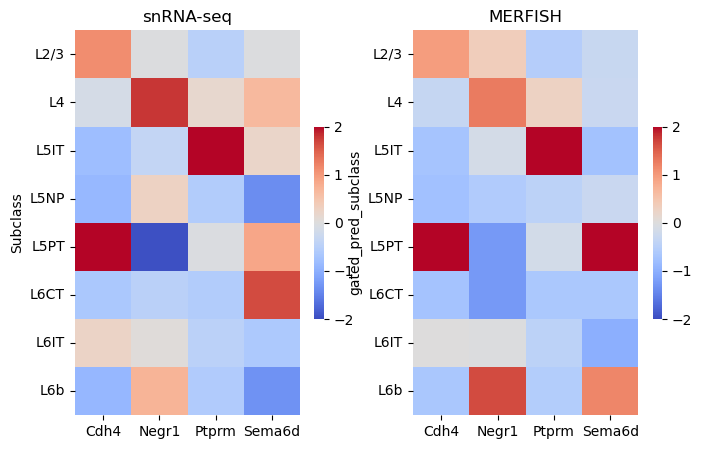

In [37]:

fig, axs = plt.subplots(1,2,figsize=(2*4,1*5))
ax = axs[0]
ax.set_title('snRNA-seq')
sns.heatmap( dfval_mean_zscore, 
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax = axs[1]
ax.set_title('MERFISH')
sns.heatmap(dfval2_mean_zscore, 
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()